# Adaptive optics loop data preprocessing for Machine Learning PSF Reconstruction (PSF-R-ML)

||||
|:---:|:---|:---|
|2026.04.10| Initial version | Dominique Humbert |




In [6]:
%matplotlib widget
import matplotlib.pyplot as plt
import h5py
import numpy as np
import pandas as pd
from matplotlib.patches import Circle


SMALL_SIZE = 20
MEDIUM_SIZE = 22
BIGGER_SIZE = 25
GPU = True
outputDir = "output/"
inputDir = "output/"

Parameters = "ao_metadata.txt"

diff_lim_file_name = "diff_lim_"

file_names = ["ao_DM_", "ao_lightfield_", "ao_psf_", "ao_rwfe_", "ao_WFS_"]

metadata = pd.read_csv(inputDir + Parameters, sep="\t", header=None, skiprows=1, index_col=0)
metadaty_keys = metadata.keys()
iterationPerBatch = int(metadata.loc["batchItSize"][1])
nActWSF = int(metadata.loc["nActWSF"][1])
edge_act = metadata.loc["edge_act"][1]
act_tot = nActWSF + 2*edge_act

In [7]:
print(iterationPerBatch)
print(edge_act)

274
0.5


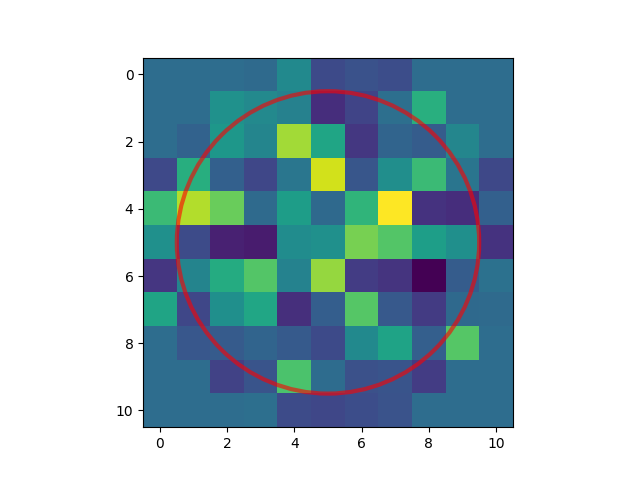

In [8]:
with h5py.File(inputDir+"ao_DM_"+str(1)+".h5", 'r') as temp:
    key = list(temp.keys())
    ao_DM = temp[key[0]][()][2,:]

def circle_to_square(positions_1d, Nact1D=11):
    dm_array = np.zeros((Nact1D, Nact1D))
    y, x = np.ogrid[:Nact1D, :Nact1D]
    center = (Nact1D - 1) / 2
    dist_sq = (x - center)**2 + (y - center)**2
    # Get indices of N closest points to center
    sorted_indices = np.argsort(dist_sq.flatten())
    active_indices = sorted_indices[:len(positions_1d)]
    dm_array.flat[active_indices] = positions_1d
    return dm_array

dm_array = circle_to_square(ao_DM, Nact1D=int(act_tot))


plt.close(0)
plt.figure(0)
plt.imshow(dm_array)
circle = Circle((5, 5), 4.5, color='red', fill=False, linewidth=3,alpha=0.6)
plt.gca().add_patch(circle)

In [10]:
with h5py.File(inputDir+"ao_rwfe_"+str(1)+".h5", 'r') as temp:
    key = list(temp.keys())
    ao_RWFE = temp[key[0]][()]
print(ao_RWFE[0])


[0.55847883 0.28216956 0.14927068 0.08953292 0.06673583 0.05978559
 0.05827562 0.05830597 0.05873091 0.05916676 0.06001969 0.06110323
 0.06184695 0.06207748 0.06195047 0.0617427  0.06168356 0.06192338
 0.06220251 0.06245142 0.0626969  0.06254862 0.06227881 0.06198192
 0.06168657 0.06139115 0.06117168 0.06075826 0.06011057 0.05987491
 0.05994067 0.05955252 0.05926405 0.05919317 0.05892003 0.05846362
 0.05809896 0.05796904 0.05824806 0.05867559 0.05909093 0.05978249
 0.06018469 0.06021768 0.06005135 0.05962967 0.05915165 0.05872311
 0.05831011 0.05817037 0.05805522 0.05807238 0.05817043 0.05817532
 0.0583921  0.05895075 0.05953457 0.05995567 0.06031145 0.06083248
 0.06135743 0.0616491  0.062071   0.06253648 0.06277858 0.06266655
 0.06192258 0.0607765  0.05947832 0.05821967 0.05750964 0.05711994
 0.0566371  0.05633881 0.05621356 0.05626561 0.05657302 0.05717203
 0.05756386 0.05763666 0.05751696 0.05768623 0.05797605 0.0580058
 0.0580811  0.05794008 0.05785263 0.05786615 0.05774197 0.05752

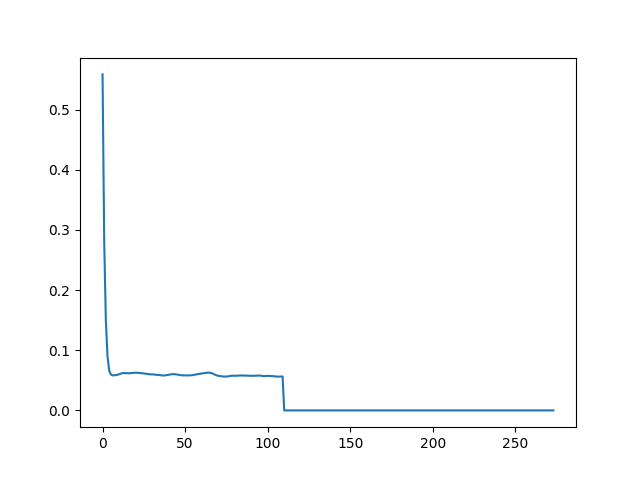

In [12]:
plt.close(0)
plt.figure(0)
plt.plot(ao_RWFE[0])
# plt.xlim(0, 10)
plt.show()


## Load datasets

In [ ]:


# for file_name in file_names:  
#     if file_name == file_names[0]:
#         for i in range(1, 5+1):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_DM = temp[key[0]][()]
#     elif file_name == file_names[1]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_lightfield = temp[key[0]][()]
#     elif file_name == file_names[2]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_psf = temp[key[0]][()]
#     elif file_name == file_names[3]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_rwfe = temp[key[0]][()]
#     elif file_name == file_names[4]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_WFS = temp[key[0]][()]




# temp = h5py.File(inputDir+"ao_diff_limited_.h5", 'r')
# key = list(temp.keys())
# diff_lim = temp[key[0]][()]

# plt.close(0)
# plt.figure()
# plt.imshow(diff_lim**(1/2))

In [ ]:
# # print(ao_DM.shape)
# plt.close(0)
# plt.figure(0)
# plt.imshow(ao_DM[60,:].reshape(11,11))
# circle = Circle((5, 5), 4.5, color='red', fill=False, linewidth=3,alpha=0.6)
# plt.gca().add_patch(circle)


# print(ao_lightfield.shape)
# # print(ao_DM[:,0])
# plt.close(1)
# plt.figure(1)
# plt.imshow(ao_lightfield[50,:,:]**(1/4))

# print(ao_psf.shape)
# # print(ao_DM[:,0])
# plt.close(2)
# plt.figure(2)
# plt.imshow(ao_psf[88,:,:])
